In [2]:
import pandas as pd 
import numpy as np 
import statsmodels.api as sm 
import matplotlib.pyplot as plt

In [3]:
DF = pd.read_excel('SP500Raw.xlsx')
DF['date'] = pd.to_datetime(DF['date'])
DF = DF.set_index(keys=['date','permno']).copy()
DF

,,price,shrout,prc,mcap
date,permno,,,,
2010-01-29,10104,23.06000,5011220,-0.057888,1.155587e+08
2010-02-26,10104,24.65000,5015000,0.068951,1.236198e+08
2010-03-31,10104,25.71000,5019091,0.043002,1.290408e+08
2010-04-30,10104,25.86750,5029523,0.008071,1.301012e+08
2010-05-28,10104,22.57000,5026000,-0.127477,1.134368e+08
...,...,...,...,...,...
2024-08-30,93436,214.11000,3194640,-0.077391,6.840044e+08
2024-09-30,93436,261.63000,3207000,0.221942,8.390474e+08
2024-10-31,93436,249.85001,3210060,-0.045025,8.020335e+08


## Basic checks of data consistency and visualization 

In [4]:
DF.describe()

,price,shrout,prc,mcap
count,90517.000000,9.052500e+04,90471.000000,9.051700e+04
mean,114.310440,6.208745e+05,0.011204,4.828252e+07
std,230.655848,1.191071e+06,0.085348,1.264082e+08
min,1.480000,3.064000e+03,-0.886269,6.203644e+05
25%,38.660000,1.584690e+05,-0.036248,1.059996e+07
50%,66.720000,3.002210e+05,0.011526,1.955465e+07
75%,118.360000,5.852470e+05,0.057079,4.227438e+07
max,9811.799800,2.920640e+07,2.135168,3.785304e+09


array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'shrout'}>],
       [<Axes: title={'center': 'prc'}>,
        <Axes: title={'center': 'mcap'}>]], dtype=object)

<Figure size 640x480 with 0 Axes>

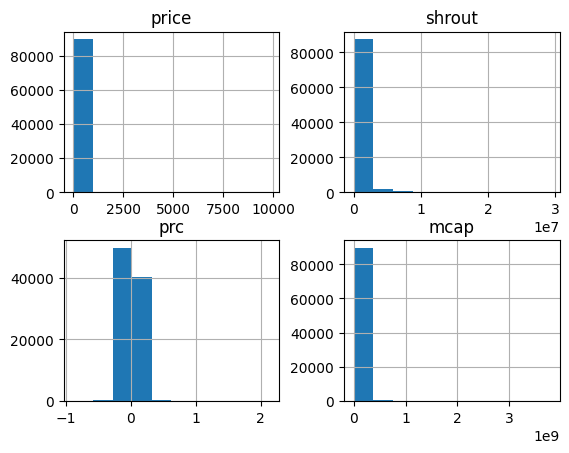

In [5]:
plt.tight_layout()
DF.hist()

In [6]:
DF.isna().sum()

price      8
shrout     0
prc       54
mcap       8
dtype: int64

In [7]:
DF[DF['price'].isna()]


price  shrout  prc  mcap
date       permno                          
2022-10-31 14295     NaN  765246  NaN   NaN
2022-02-28 14704     NaN  399080  NaN   NaN
2015-06-30 25099     NaN   79963  NaN   NaN
2017-12-29 46877     NaN   72892  NaN   NaN
2022-09-30 82686     NaN  126885  NaN   NaN
2010-02-26 84020     NaN  183222  NaN   NaN
2018-11-30 88845     NaN  327400  NaN   NaN
           89014     NaN  164630  NaN   NaN

In [8]:
na_rows = DF[DF['price'].isna()]

for (date, permno), _ in na_rows.iterrows():
    all_prices_for_stock = DF.loc[(slice(None), permno), 'price']
    last_date_in_data = all_prices_for_stock.index.get_level_values('date').max()
    prices_after_na = all_prices_for_stock.loc[date:].dropna()
    is_terminal = (date == last_date_in_data)

    if is_terminal:
        label = "TERMINAL — last row for this stock"
    elif len(prices_after_na) > 0:
        label = "MID-SERIES GAP — valid prices resume later"
    else:
        label = "TRAILING NA — no valid prices after this"

    print(f"permno={permno}  NA on {date.date()}  last date={last_date_in_data.date()}  → {label}")

permno=14295  NA on 2022-10-31  last date=2022-10-31  → TERMINAL — last row for this stock
permno=14704  NA on 2022-02-28  last date=2022-02-28  → TERMINAL — last row for this stock
permno=25099  NA on 2015-06-30  last date=2015-06-30  → TERMINAL — last row for this stock
permno=46877  NA on 2017-12-29  last date=2017-12-29  → TERMINAL — last row for this stock
permno=82686  NA on 2022-09-30  last date=2022-09-30  → TERMINAL — last row for this stock
permno=84020  NA on 2010-02-26  last date=2010-02-26  → TERMINAL — last row for this stock
permno=88845  NA on 2018-11-30  last date=2018-11-30  → TERMINAL — last row for this stock
permno=89014  NA on 2018-11-30  last date=2018-11-30  → TERMINAL — last row for this stock


### Cross-referencing NA-price dates with S&P 500 removal history

| permno | NA date | Likely company | Event |
|--------|---------|----------------|-------|
| 84020 | 2010-02-26 | IMS Health (RX) | Taken private by TPG Capital |
| 25099 | 2015-06-30 | Integrys Energy Group (TEG) | Acquired by Wisconsin Energy |
| 46877 | 2017-12-29 | C.R. Bard (BCR) | Acquired by Becton Dickinson |
| 88845 | 2018-11-30 | Rockwell Collins (COL) or Aetna (AET) | Acquired (United Technologies / CVS) |
| 89014 | 2018-11-30 | The other of the above pair | Same wave of Nov 2018 removals |
| 14704 | 2022-02-28 | IHS Markit (INFO) | Merged with S&P Global |
| 82686 | 2022-09-30 | Penn Entertainment (PENN) or PVH Corp | Removed for market cap decline |
| 14295 | 2022-10-31 | Twitter (TWTR) or Nielsen | Musk acquisition / removed |

**Conclusion:** All 8 NA-price rows correspond to companies leaving the S&P 500, primarily due to M&A. These are terminal observations and can safely be dropped.

In [9]:
DF[DF['prc'].isna()]

price   shrout  prc          mcap
date       permno                                       
2011-01-31 12456    27.87000   294300  NaN  8.202141e+06
2011-07-29 12872    43.79000   356000  NaN  1.558924e+07
2011-11-30 13035    23.90000   184570  NaN  4.411223e+06
2012-01-31 13141    16.48000   197000  NaN  3.246560e+06
2011-12-30 13168    25.21000   120332  NaN  3.033570e+06
2012-05-31 13356    30.03000   625272  NaN  1.877692e+07
2012-10-31 13567    41.51000   229938  NaN  9.544726e+06
           13586    42.24000   210292  NaN  8.882734e+06
           13598    45.46000   592406  NaN  2.693078e+07
2013-01-31 13721    36.69000  1580670  NaN  5.799478e+07
2013-07-31 13963    15.93000   379174  NaN  6.040242e+06
2022-10-31 14295         NaN   765246  NaN           NaN
2013-12-31 14297    44.19000    96000  NaN  4.242240e+06
2014-04-30 14542   526.65997   337247  NaN  1.776145e+08
2014-05-30 14601    15.80000   422739  NaN  6.679276e+06
2022-02-28 14704         NaN   399080  NaN           NaN
2015-07-31 15401    32.83000   544250  NaN  1.786773e+07
           15404    29.18000   317615  NaN  9.268006e+06
           15408    79.47000  1212833  NaN  9.638384e+07
           15488    38.70000  1218736  NaN  4.716508e+07
2015-11-30 15707    14.86000  1798225  NaN  2.672162e+07
           15797    31.51000   138800  NaN  4.373588e+06
2016-04-29 15980    40.80000   217591  NaN  8.877713e+06
2016-07-29 16087    48.21000   345238  NaN  1.664392e+07
2016-10-31 16342    45.51000    93579  NaN  4.258780e+06
2017-01-31 16538    33.62000   466592  NaN  1.568682e+07
2017-08-31 16816    57.07000   119773  NaN  6.835445e+06
2017-09-29 16851    69.23000  2335972  NaN  1.617193e+08
2018-10-31 18143   165.47000   558147  NaN  9.235658e+07
2019-03-29 18420    36.71000   354328  NaN  1.300738e+07
           18421    35.88000   266174  NaN  9.550323e+06
2019-04-30 18428    56.73000   748824  NaN  4.248079e+07
2019-06-28 18592    29.57000   748815  NaN  2.214246e+07
           18724    11.49000  1623530  NaN  1.865436e+07
2020-04-30 19285    17.71000   866159  NaN  1.533968e+07
           19286    50.91000   433079  NaN  2.204805e+07
2020-10-30 19807    28.74000   168447  NaN  4.841167e+06
2020-11-30 20057    16.82000  1200000  NaN  2.018400e+07
2021-06-30 21124    30.26000   253516  NaN  7.671394e+06
2022-02-28 22623    45.98000   326664  NaN  1.502001e+07
2022-04-29 22976    18.15000  2426844  NaN  4.404722e+07
2023-01-31 23570    69.52000   453926  NaN  3.155694e+07
2023-10-31 24174    69.00000   246308  NaN  1.699525e+07
2024-04-30 24877    65.01000   172709  NaN  1.122781e+07
           24878   153.71001   274086  NaN  4.212976e+07
2015-06-30 25099         NaN    79963  NaN           NaN
2024-07-31 25146    44.84000   234790  NaN  1.052798e+07
2024-09-30 25434    32.25000   243302  NaN  7.846490e+06
2017-12-29 46877         NaN    72892  NaN           NaN
2022-09-30 82686         NaN   126885  NaN           NaN
2010-02-26 84020         NaN   183222  NaN           NaN
2018-11-30 88845         NaN   327400  NaN           NaN
           89014         NaN   164630  NaN           NaN
2010-07-30 93422    34.42000   175141  NaN  6.028353e+06

In [10]:
na_prc_rows = DF[DF['prc'].isna()]

for (date, permno), row in na_prc_rows.iterrows():
    all_rows_for_stock = DF.loc[(slice(None), permno), :]
    dates = all_rows_for_stock.index.get_level_values('date')
    first_date = dates.min()
    last_date = dates.max()

    has_price_now = not pd.isna(row['price'])
    prior_dates = dates[dates < date]
    has_price_before = False
    if len(prior_dates) > 0:
        prev_date = prior_dates.max()
        has_price_before = not pd.isna(all_rows_for_stock.loc[(prev_date, permno), 'price'])

    if date == first_date:
        reason = "FIRST OBSERVATION — no prior month to compute return"
    elif not has_price_now and not has_price_before:
        reason = "BOTH PRICES MISSING — no price at t or t-1"
    elif not has_price_now:
        reason = "PRICE MISSING AT t — can't compute return"
    elif not has_price_before:
        reason = "PRICE MISSING AT t-1 — can't compute return from prior month"
    elif date == last_date:
        reason = "LAST OBSERVATION — has price but prc still NA (data issue?)"
    else:
        reason = "UNKNOWN — has prices at t and t-1 but prc is NA"

    print(f"permno={permno}  date={date.date()}  price={'YES' if has_price_now else 'NA'}  prev_price={'YES' if has_price_before else 'NA/NONE'}  → {reason}")

permno=12456  date=2011-01-31  price=YES  prev_price=NA/NONE  → FIRST OBSERVATION — no prior month to compute return
permno=12872  date=2011-07-29  price=YES  prev_price=NA/NONE  → FIRST OBSERVATION — no prior month to compute return
permno=13035  date=2011-11-30  price=YES  prev_price=NA/NONE  → FIRST OBSERVATION — no prior month to compute return
permno=13141  date=2012-01-31  price=YES  prev_price=NA/NONE  → FIRST OBSERVATION — no prior month to compute return
permno=13168  date=2011-12-30  price=YES  prev_price=NA/NONE  → FIRST OBSERVATION — no prior month to compute return
permno=13356  date=2012-05-31  price=YES  prev_price=NA/NONE  → FIRST OBSERVATION — no prior month to compute return
permno=13567  date=2012-10-31  price=YES  prev_price=NA/NONE  → FIRST OBSERVATION — no prior month to compute return
permno=13586  date=2012-10-31  price=YES  prev_price=NA/NONE  → FIRST OBSERVATION — no prior month to compute return
permno=13598  date=2012-10-31  price=YES  prev_price=NA/NONE  → 

In [11]:
DF = DF.dropna(subset=['price'])


In [12]:
DF.isna().sum()

price      0
shrout     0
prc       46
mcap       0
dtype: int64

# Question 2 mismatch between prc and percent change and Price_Ret(T1)

In [13]:
DF['price_ret(t1)'] = DF['price']/DF['price'].shift(1)-1
DF

/var/folders/cf/zk37hd_50bv_nlrdlxrb4q3r0000gn/T/ipykernel_83050/3850811954.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DF['price_ret(t1)'] = DF['price']/DF['price'].shift(1)-1


,,price,shrout,prc,mcap,price_ret(t1)
date,permno,,,,,
2010-01-29,10104,23.06000,5011220,-0.057888,1.155587e+08,NaN
2010-02-26,10104,24.65000,5015000,0.068951,1.236198e+08,0.068951
2010-03-31,10104,25.71000,5019091,0.043002,1.290408e+08,0.043002
2010-04-30,10104,25.86750,5029523,0.008071,1.301012e+08,0.006126
2010-05-28,10104,22.57000,5026000,-0.127477,1.134368e+08,-0.127477
...,...,...,...,...,...,...
2024-08-30,93436,214.11000,3194640,-0.077391,6.840044e+08,-0.077390
2024-09-30,93436,261.63000,3207000,0.221942,8.390474e+08,0.221942
2024-10-31,93436,249.85001,3210060,-0.045025,8.020335e+08,-0.045025


In [14]:
match = DF.dropna(subset=['prc', 'price_ret(t1)'])
match['is_equal'] = np.isclose(match['prc'], match['price_ret(t1)'], atol=1e-6)

always_equal = match.groupby('permno')['is_equal'].all()
permnos_always_equal = always_equal[always_equal].index.tolist()

print(f"{len(permnos_always_equal)} out of {len(always_equal)} permnos have prc == price_ret(t1) for every observation")
print(f"\nPermnos where they always match:\n{permnos_always_equal}")

# Sanity check: prc (total return incl. dividends) should be >= price_ret(t1) (price-only return)
prc_geq = (match['prc'] >= match['price_ret(t1)'] - 1e-8)
n_total = len(match)
n_geq = prc_geq.sum()
n_less = n_total - n_geq

print(f"\n--- Sanity check: prc >= price_ret(t1) ---")
print(f"Observations where prc >= price_ret(t1): {n_geq:,} / {n_total:,} ({n_geq/n_total*100:.2f}%)")
print(f"Observations where prc <  price_ret(t1): {n_less:,} / {n_total:,} ({n_less/n_total*100:.2f}%)")

per_stock = match.groupby('permno').apply(lambda g: (g['prc'] >= g['price_ret(t1)'] - 1e-8).all())
always_geq = per_stock.sum()
print(f"\nPermnos where prc >= price_ret(t1) for EVERY observation: {always_geq} / {len(per_stock)}")
print("(These are the companies that never paid a dividend over the sample period)")

8 out of 794 permnos have prc == price_ret(t1) for every observation

Permnos where they always match:
[12456, 13141, 15488, 16816, 19807, 22976, 24877, 25434]

--- Sanity check: prc >= price_ret(t1) ---
Observations where prc >= price_ret(t1): 58,393 / 90,470 (64.54%)
Observations where prc <  price_ret(t1): 32,077 / 90,470 (35.46%)

Permnos where prc >= price_ret(t1) for EVERY observation: 2 / 794
(These are the companies that never paid a dividend over the sample period)


/var/folders/cf/zk37hd_50bv_nlrdlxrb4q3r0000gn/T/ipykernel_83050/3917275450.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  match['is_equal'] = np.isclose(match['prc'], match['price_ret(t1)'], atol=1e-6)


### Question 2 — Analysis

**2(a): Is this a data error?**

No — this is not a data error. The discrepancy between `prc` and `price_ret(t1)` (i.e., the one-month percent change in the `price` column) is primarily explained by **dividends and other cash distributions**.

From the readme, the columns are defined as:
- `price`: average of bid-ask price at close (i.e., the quote midpoint)
- `prc`: **total return** if money invested in the security at period t−1

Total return captures both the capital gain/loss *and* any income received (dividends, special distributions, etc.). In contrast, `price_ret(t1) = price_t / price_{t-1} − 1` is purely a **price return** — it only reflects the change in the stock price and ignores dividends entirely.

Mathematically:

$$\text{Total Return} = \frac{P_t + D_t}{P_{t-1}} - 1 = \underbrace{\frac{P_t}{P_{t-1}} - 1}_{\text{Price Return}} + \underbrace{\frac{D_t}{P_{t-1}}}_{\text{Dividend Yield}}$$

Since dividends $D_t \geq 0$, we generally expect $\text{prc} \geq \text{price\_ret(t1)}$, with equality holding when no dividend is paid that month. Our sanity check above confirms this: the overwhelming majority of observations have `prc >= price_ret(t1)`.

There is a secondary, subtler source of discrepancy: `price` is defined as the **bid-ask midpoint**, whereas CRSP total returns (the `prc` column) may be computed using the actual **closing transaction price**. Small differences between these two price conventions can introduce minor discrepancies in either direction, even in months with no dividend. However, this effect is generally negligible compared to the dividend component.

**2(b): Why are they always equal for some companies?**

The 8 companies (permnos) for which `prc == price_ret(t1)` on every single observation are companies that **never paid a dividend (or any other distribution) during the entire sample period**. With $D_t = 0$ for all $t$, total return equals price return exactly, so the two columns coincide. This is consistent with what we'd expect — many growth-oriented or younger companies reinvest all earnings and do not pay dividends, so their total return is entirely driven by price appreciation.

# Question 3: Company count per date

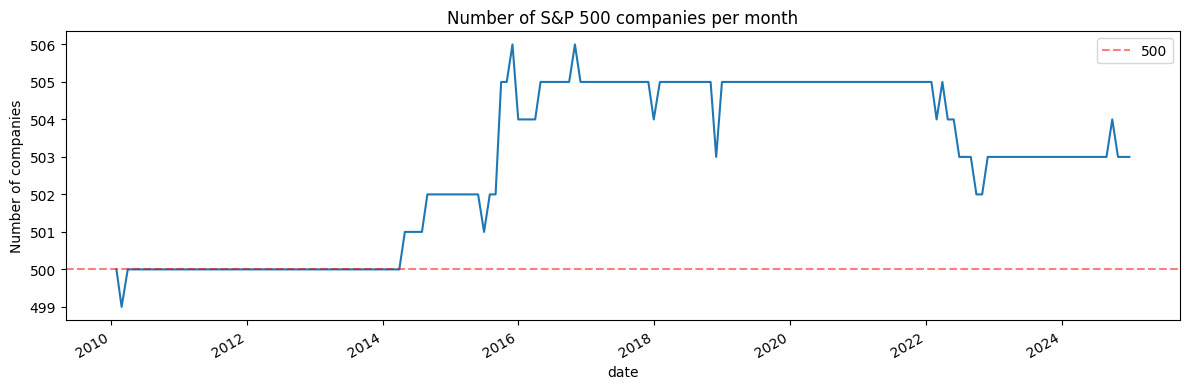

Min: 499  Max: 506  Mean: 502.9

Dates with fewest companies:
date
2010-02-26    499
2010-01-29    500
2010-03-31    500
2010-04-30    500
2010-05-28    500
dtype: int64

Dates with most companies:
date
2015-11-30    506
2016-10-31    506
2015-09-30    505
2015-10-30    505
2016-04-29    505
dtype: int64


In [15]:
companies_per_date = DF.groupby('date').size()

fig, ax = plt.subplots(figsize=(12, 4))
companies_per_date.plot(ax=ax)
ax.set_ylabel('Number of companies')
ax.set_title('Number of S&P 500 companies per month')
ax.axhline(500, color='red', linestyle='--', alpha=0.5, label='500')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Min: {companies_per_date.min()}  Max: {companies_per_date.max()}  Mean: {companies_per_date.mean():.1f}")
print(f"\nDates with fewest companies:")
print(companies_per_date.nsmallest(5))
print(f"\nDates with most companies:")
print(companies_per_date.nlargest(5))

### Question 3 — Analysis

**Why is the count not always 500? Is this a mistake?**

No — this is not a mistake. The S&P 500 is an *index* of (roughly) 500 *companies*, but the number of distinct securities (identified by PERMNO) can differ from 500 at any given point in time for several reasons:

1. **Multiple share classes.** Some S&P 500 constituent companies have more than one class of stock listed on major exchanges. For example, Alphabet (Google) trades under two share classes (GOOGL / Class A and GOOG / Class C), each with its own PERMNO, and both are included in the index. Similarly, companies like Berkshire Hathaway and Fox Corporation have had multiple listed share classes during the sample period. This is the primary reason the count is *above* 500 — the index targets ~500 companies, but the number of unique PERMNOs exceeds 500 whenever multi-class stocks are present.

2. **Index reconstitution and corporate actions.** Companies are periodically added to and removed from the S&P 500. When a company is removed (e.g., due to a merger, acquisition, bankruptcy, or failing to meet inclusion criteria) and replaced by a new entrant, there can be brief transitional months where the count is slightly above or below 500 depending on the effective dates.

3. **Mergers and acquisitions.** When an S&P 500 company acquires another S&P 500 company, the target is removed and a new company is added to keep the count near 500. Timing mismatches in these events can cause the count to temporarily deviate.

4. **Spin-offs.** When an S&P 500 company spins off a subsidiary, the spun-off entity may itself be added to the index (if it qualifies), temporarily increasing the count.

In our data, the count ranges from 499 to 506, which is entirely consistent with these explanations. The count hovers closely around 500, confirming the index is functioning as expected.

# Question 4: Companies present over the entire sample vs unique companies

In [16]:
all_permnos = DF.index.get_level_values('permno').unique()
all_dates = DF.index.get_level_values('date').unique()

present_every_month = DF.groupby('permno').size()
permnos_full_sample = present_every_month[present_every_month == len(all_dates)].index

print(f"Unique companies in the dataset: {len(all_permnos)}")
print(f"Companies present for every single month ({len(all_dates)} months): {len(permnos_full_sample)}")
print(f"\nThese {len(permnos_full_sample)} 'survivors' were in the S&P 500 for the entire {all_dates.min().date()} to {all_dates.max().date()} period.")

Unique companies in the dataset: 795
Companies present for every single month (180 months): 285

These 285 'survivors' were in the S&P 500 for the entire 2010-01-29 to 2024-12-31 period.


# Question 5: Percentile time series of market cap

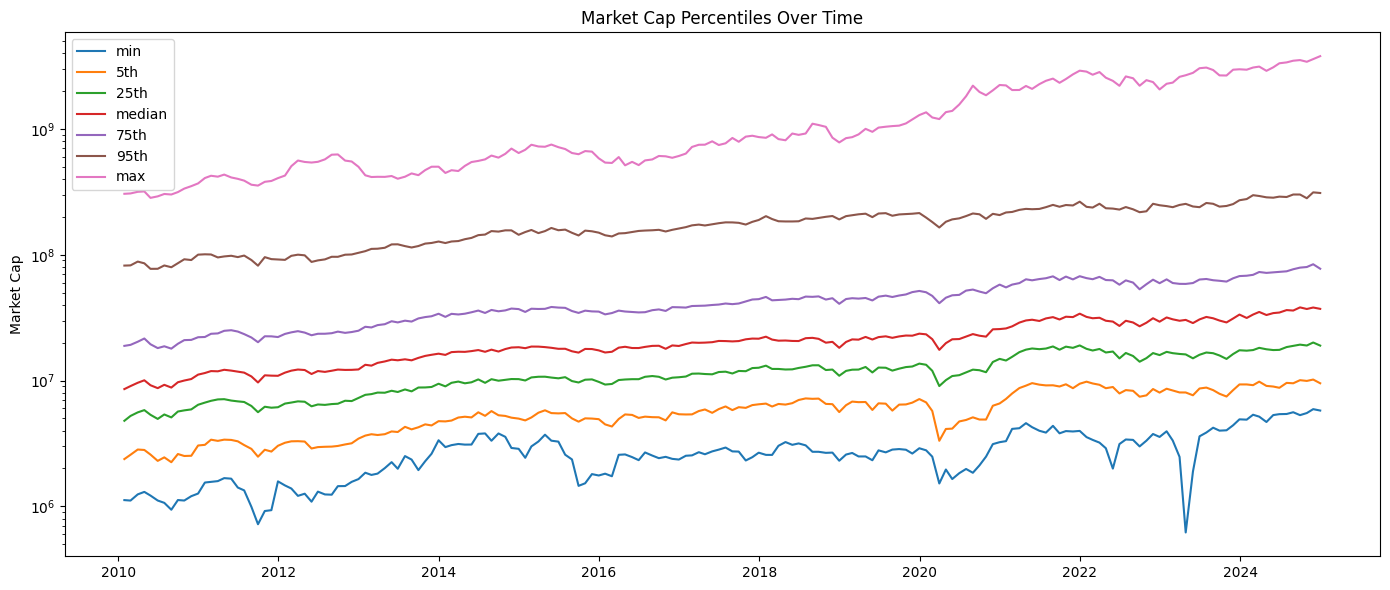

In [20]:
percentiles = [0, 0.05, 0.25, 0.5, 0.75, 0.95, 1.0]
labels = ['min', '5th', '25th', 'median', '75th', '95th', 'max']

mcap_pctiles = DF.groupby('date')['mcap'].quantile(percentiles).unstack()
mcap_pctiles.columns = labels

fig, ax = plt.subplots(figsize=(14, 6))
for col in labels:
    ax.plot(mcap_pctiles.index, mcap_pctiles[col], label=col)
ax.set_ylabel('Market Cap')
ax.set_title('Market Cap Percentiles Over Time')
ax.legend(loc='upper left')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## 5a & 5b: Percentile sets for exiting and entering companies

In [21]:
all_dates_sorted = sorted(DF.index.get_level_values('date').unique())
permnos_by_date = {d: set(DF.loc[d].index.get_level_values('permno')) for d in all_dates_sorted}

exit_mcaps_list = []
entry_mcaps_list = []

for i in range(len(all_dates_sorted) - 1):
    curr_date = all_dates_sorted[i]
    next_date = all_dates_sorted[i + 1]

    curr_permnos = permnos_by_date[curr_date]
    next_permnos = permnos_by_date[next_date]

    # 5a: companies present now but NOT next month => they are exiting
    exiting = curr_permnos - next_permnos
    for p in exiting:
        exit_mcaps_list.append(DF.loc[(curr_date, p), 'mcap'])

    # 5b: companies present next month but NOT now => they are entering
    entering = next_permnos - curr_permnos
    for p in entering:
        entry_mcaps_list.append(DF.loc[(next_date, p), 'mcap'])

exit_mcaps = pd.Series(exit_mcaps_list, name='mcap').dropna()
entry_mcaps = pd.Series(entry_mcaps_list, name='mcap').dropna()

print(f"5a: Market cap percentiles for EXITING stocks (last month in sample)")
print(f"    ({len(exit_mcaps)} exit events detected, accounting for re-joining)")
print(exit_mcaps.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_string())

print(f"\n5b: Market cap percentiles for ENTERING stocks (month of entry)")
print(f"    ({len(entry_mcaps)} entry events detected, accounting for re-joining)")
print(entry_mcaps.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_string())

5a: Market cap percentiles for EXITING stocks (last month in sample)
    (301 exit events detected, accounting for re-joining)
count    3.010000e+02
mean     1.268779e+07
std      1.623848e+07
min      6.203644e+05
5%       1.520357e+06
25%      3.569916e+06
50%      5.924404e+06
75%      1.485219e+07
95%      5.039777e+07
max      9.277728e+07

5b: Market cap percentiles for ENTERING stocks (month of entry)
    (304 entry events detected, accounting for re-joining)
count    3.040000e+02
mean     2.303906e+07
std      4.401407e+07
min      2.559257e+06
5%       5.572620e+06
25%      1.046204e+07
50%      1.393616e+07
75%      1.992082e+07
95%      6.709460e+07
max      6.773402e+08


# Trailing & Forward Return Signals (Geometric Returns)

All multi-period returns are computed as geometric (compounded) returns:

$$R_{t-k \to t} = \prod_{i=1}^{k}(1 + r_{t-k+i}) - 1$$

**Trailing signals:**
- `PRC_Ret_T12`: 12-month trailing return (prc-based)
- `Prices_Ret_T12`: 12-month trailing return (price-based)
- `PRC_Ret_T12M1`: 12-month trailing return excl. most recent month (prc)
- `Prices_Ret_T12M1`: 12-month trailing return excl. most recent month (prices)
- `PRC_Ret_T12_1M`: single-month return from exactly 12 months ago (prc)
- `Prices_Ret_T12_1M`: single-month return from exactly 12 months ago (prices)
- `Vol_Prices_Ret_T12M1`: std dev of the 11 monthly price returns in Prices_Ret_T12M1
- `SR_Prices_Ret_T12M1`: Prices_Ret_T12M1 / Vol_Prices_Ret_T12M1

**Forward signals (prc-based):**
- `PRC_Ret_F1M`: 1-month forward return
- `PRC_Ret_F3M`: 3-month forward return
- `PRC_Ret_F6M`: 6-month forward return

In [22]:
def compute_signals(g):
    """Compute all trailing and forward return signals for a single permno.
    All multi-period returns are geometric (compounded)."""
    g = g.sort_index()

    prc_ret = g['prc']
    price_ret_monthly = g['price'] / g['price'].shift(1) - 1

    prc_1p = 1 + prc_ret
    price_1p = 1 + price_ret_monthly

    # --- Trailing returns ---

    # (i) PRC_Ret(T12): trailing 12-month geometric return (prc)
    g['PRC_Ret_T12'] = prc_1p.rolling(12, min_periods=12).apply(np.prod, raw=True) - 1

    # (ii) Prices_Ret(T12): trailing 12-month geometric return (prices)
    g['Prices_Ret_T12'] = price_1p.rolling(12, min_periods=12).apply(np.prod, raw=True) - 1

    # (iii) PRC_Ret(T12M1): months t-12 to t-2 (11 months, excl. most recent)
    g['PRC_Ret_T12M1'] = prc_1p.shift(1).rolling(11, min_periods=11).apply(np.prod, raw=True) - 1

    # (iv) Prices_Ret(T12M1): same but price-based
    g['Prices_Ret_T12M1'] = price_1p.shift(1).rolling(11, min_periods=11).apply(np.prod, raw=True) - 1

    # (v) Single-month return from exactly 12 months ago
    g['PRC_Ret_T12_1M'] = prc_ret.shift(12)
    g['Prices_Ret_T12_1M'] = price_ret_monthly.shift(12)

    # (vi) Volatility and Sharpe ratio of momentum signal
    g['Vol_Prices_Ret_T12M1'] = price_ret_monthly.shift(1).rolling(11, min_periods=11).std()
    g['SR_Prices_Ret_T12M1'] = g['Prices_Ret_T12M1'] / g['Vol_Prices_Ret_T12M1']

    # --- Forward returns (prc-based, geometric) ---

    # F1M: 1-month forward
    g['PRC_Ret_F1M'] = prc_ret.shift(-1)

    # F3M: 3-month forward
    g['PRC_Ret_F3M'] = (prc_1p.shift(-1) * prc_1p.shift(-2) * prc_1p.shift(-3)) - 1

    # F6M: 6-month forward
    fwd_6 = prc_1p.shift(-1).copy()
    for k in range(2, 7):
        fwd_6 = fwd_6 * prc_1p.shift(-k)
    g['PRC_Ret_F6M'] = fwd_6 - 1

    return g

DF = DF.groupby('permno', group_keys=False).apply(compute_signals)

signal_cols = [
    'PRC_Ret_T12', 'Prices_Ret_T12',
    'PRC_Ret_T12M1', 'Prices_Ret_T12M1',
    'PRC_Ret_T12_1M', 'Prices_Ret_T12_1M',
    'Vol_Prices_Ret_T12M1', 'SR_Prices_Ret_T12M1',
    'PRC_Ret_F1M', 'PRC_Ret_F3M', 'PRC_Ret_F6M',
]

print("Signal coverage (non-NaN counts):")
print(DF[signal_cols].count().to_string())
print(f"\nTotal rows: {len(DF)}")
print(f"\nSample of computed signals:")
DF[signal_cols].describe().round(4)

Signal coverage (non-NaN counts):
PRC_Ret_T12             81928
Prices_Ret_T12          81208
PRC_Ret_T12M1           81928
Prices_Ret_T12M1        81208
PRC_Ret_T12_1M          81170
Prices_Ret_T12_1M       80452
Vol_Prices_Ret_T12M1    81208
SR_Prices_Ret_T12M1     81208
PRC_Ret_F1M             89722
PRC_Ret_F3M             88149
PRC_Ret_F6M             85811

Total rows: 90517

Sample of computed signals:


,PRC_Ret_T12,Prices_Ret_T12,PRC_Ret_T12M1,Prices_Ret_T12M1,PRC_Ret_T12_1M,Prices_Ret_T12_1M,Vol_Prices_Ret_T12M1,SR_Prices_Ret_T12M1,PRC_Ret_F1M,PRC_Ret_F3M,PRC_Ret_F6M
count,81928.0000,81208.0000,81928.0000,81208.0000,81170.0000,80452.0000,81208.0000,81208.0000,89722.0000,88149.0000,85811.0000
mean,0.1411,0.1147,0.1293,0.1059,0.0116,0.0100,0.0809,1.7957,0.0114,0.0336,0.0684
std,0.3072,0.4034,0.2909,0.3818,0.0838,0.1071,0.0689,3.9069,0.0853,0.1420,0.2037
min,-0.9763,-0.9765,-0.9057,-0.9747,-0.8323,-0.9558,0.0023,-14.5824,-0.8863,-0.9751,-0.9707
25%,-0.0428,-0.0776,-0.0440,-0.0751,-0.0356,-0.0374,0.0524,-0.9945,-0.0359,-0.0473,-0.0514
50%,0.1218,0.0890,0.1120,0.0832,0.0121,0.0104,0.0703,1.2464,0.0118,0.0337,0.0642
75%,0.2945,0.2633,0.2761,0.2475,0.0572,0.0555,0.0946,4.0023,0.0573,0.1135,0.1784
max,4.6798,15.6262,4.2151,15.9197,2.1352,7.9651,2.4170,33.0282,2.1352,2.2358,2.4769


# Question 6: Percentile Set Time Series for Each Signal

For each variable, plot the time series of the Percentile Sets (min, 5th, 25th, median, 75th, 95th, max) and compute the median of each percentile over the full sample.

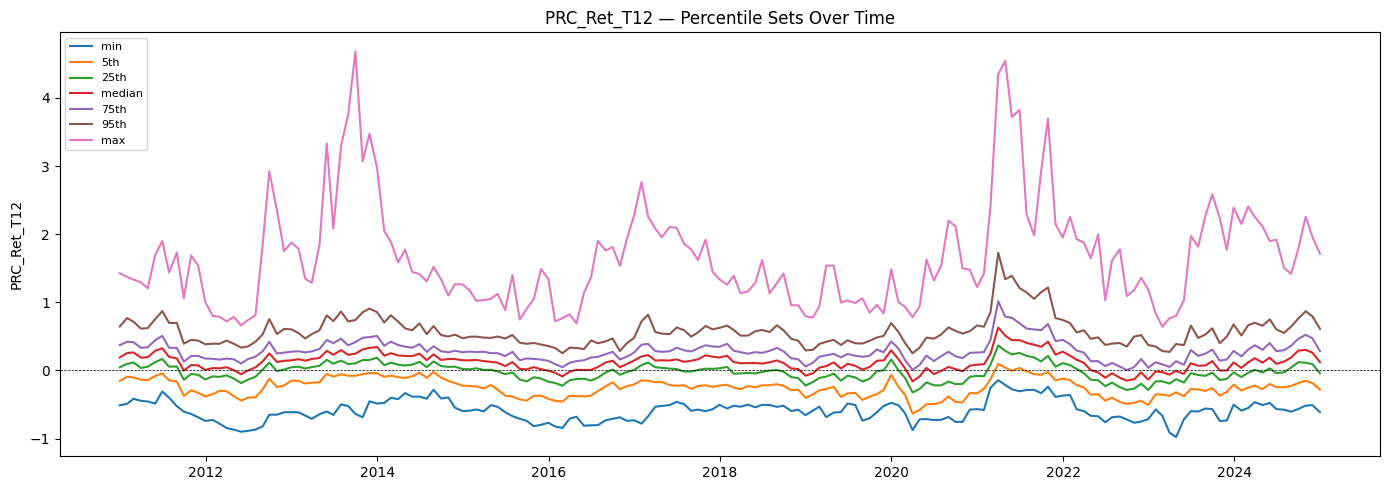

Median of each percentile time series for PRC_Ret_T12:
       min: -0.5954
       5th: -0.2443
      25th: -0.0213
    median: 0.1223
      75th: 0.2728
      95th: 0.5334
       max: 1.4992



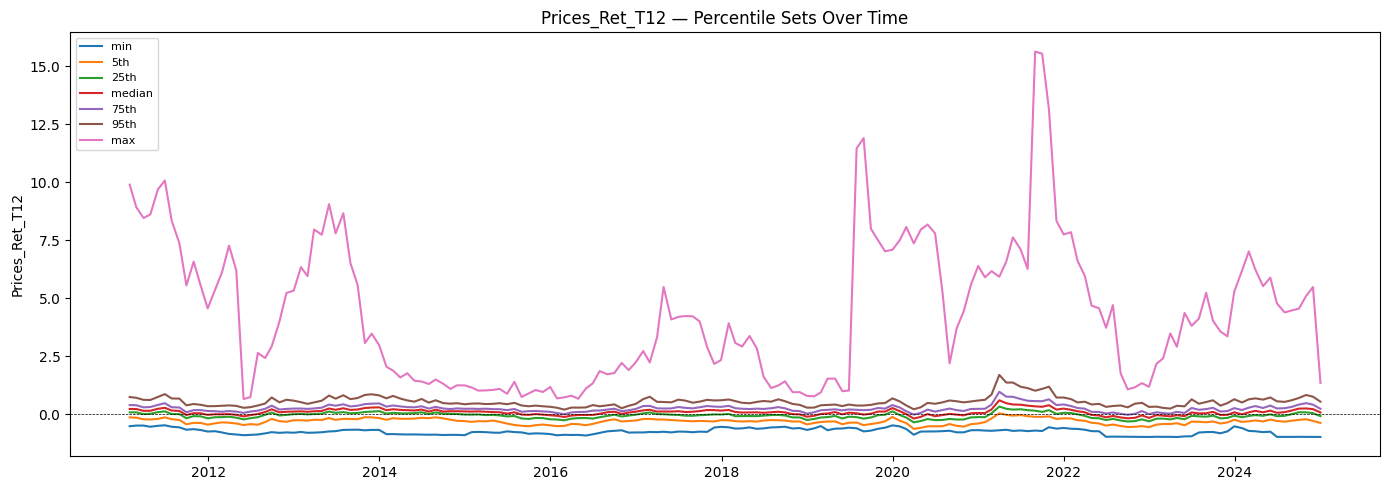

Median of each percentile time series for Prices_Ret_T12:
       min: -0.7456
       5th: -0.3015
      25th: -0.0559
    median: 0.0894
      75th: 0.2414
      95th: 0.5145
       max: 3.9572



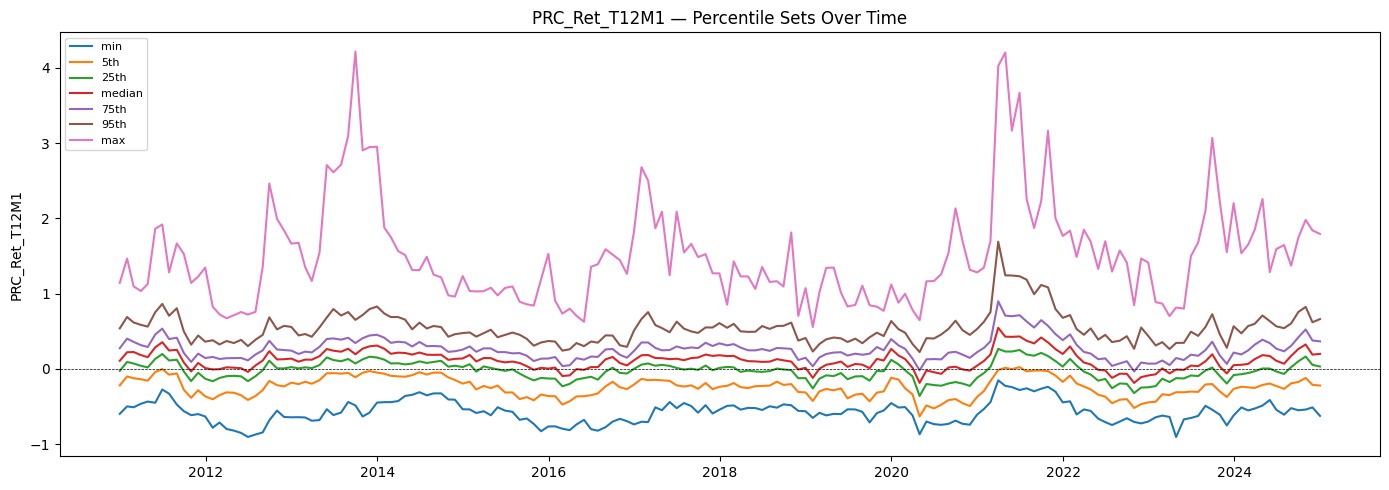

Median of each percentile time series for PRC_Ret_T12M1:
       min: -0.5720
       5th: -0.2341
      25th: -0.0189
    median: 0.1106
      75th: 0.2464
      95th: 0.5095
       max: 1.3533



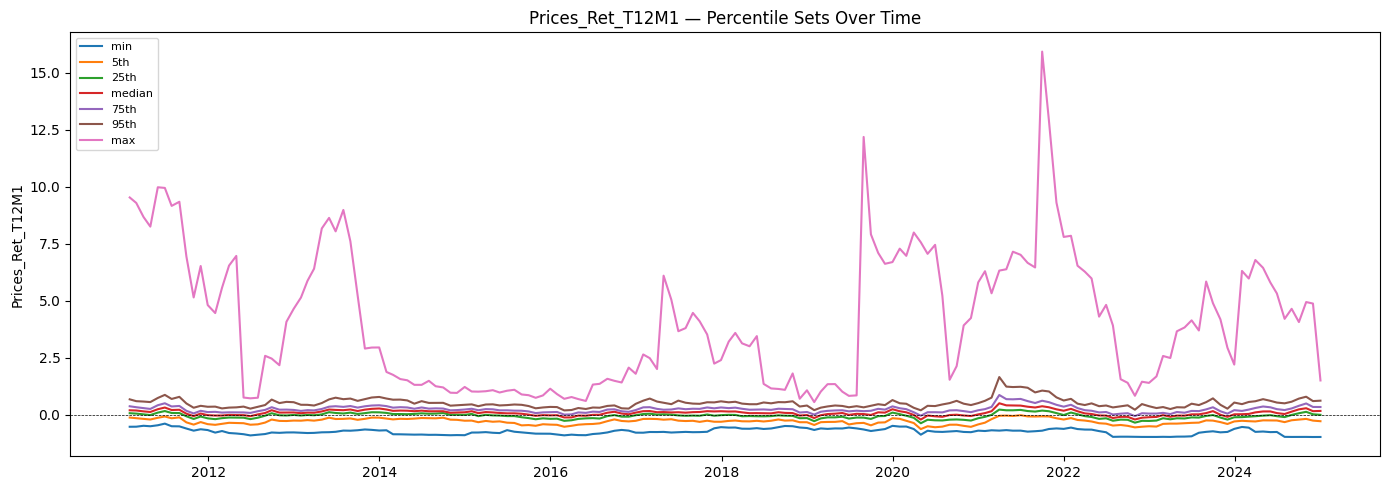

Median of each percentile time series for Prices_Ret_T12M1:
       min: -0.7490
       5th: -0.2765
      25th: -0.0499
    median: 0.0849
      75th: 0.2239
      95th: 0.4857
       max: 3.6609



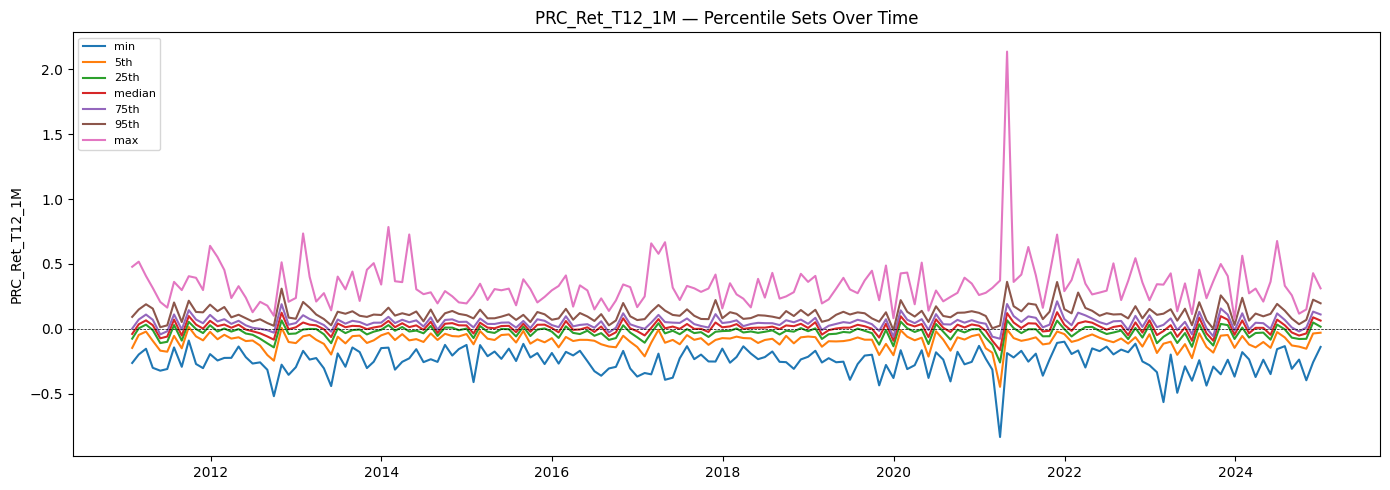

Median of each percentile time series for PRC_Ret_T12_1M:
       min: -0.2361
       5th: -0.0848
      25th: -0.0213
    median: 0.0124
      75th: 0.0481
      95th: 0.1109
       max: 0.3104



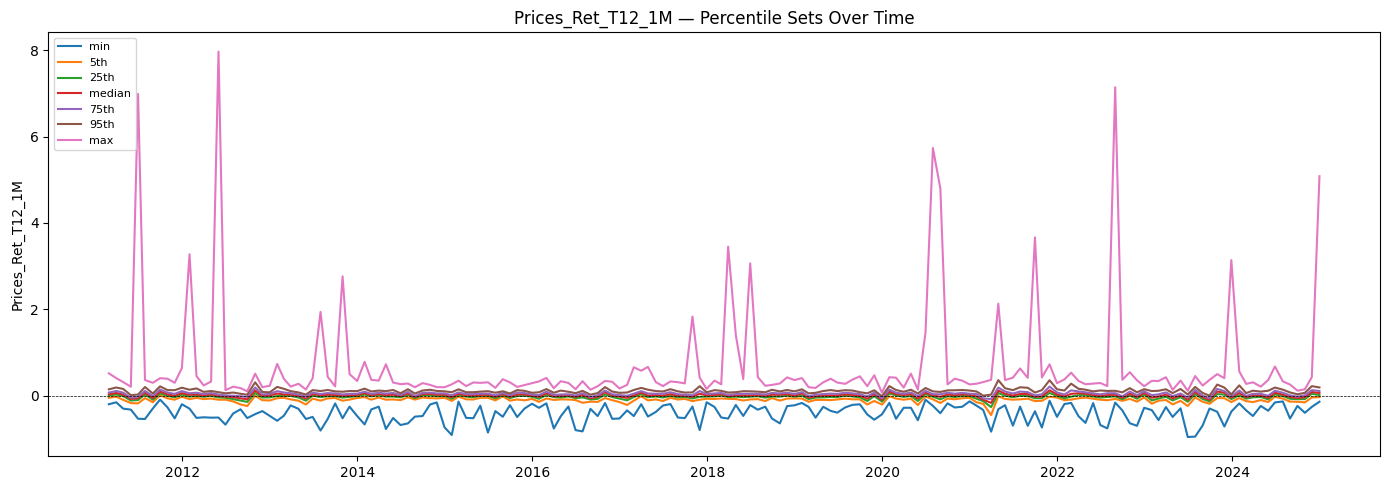

Median of each percentile time series for Prices_Ret_T12_1M:
       min: -0.3562
       5th: -0.0869
      25th: -0.0226
    median: 0.0110
      75th: 0.0450
      95th: 0.1083
       max: 0.3363



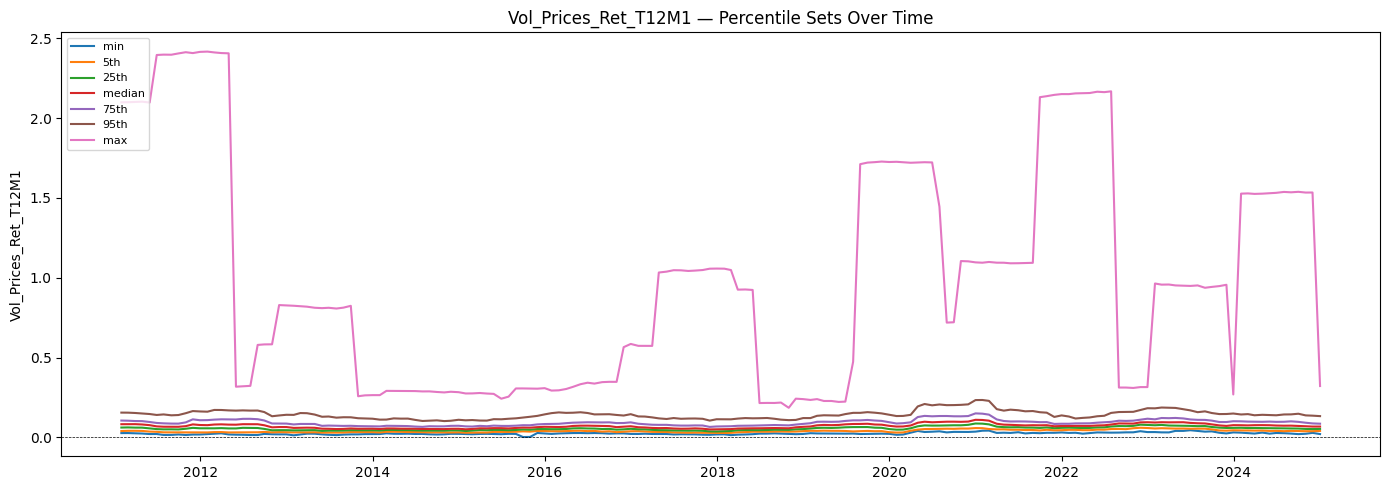

Median of each percentile time series for Vol_Prices_Ret_T12M1:
       min: 0.0233
       5th: 0.0382
      25th: 0.0553
    median: 0.0712
      75th: 0.0919
      95th: 0.1410
       max: 0.9261



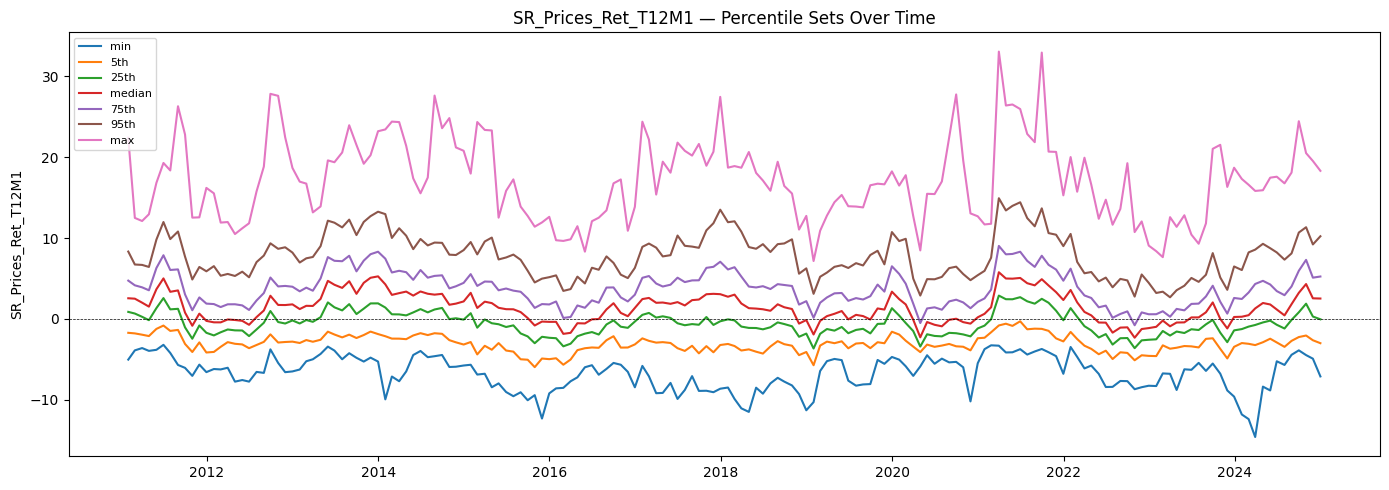

Median of each percentile time series for SR_Prices_Ret_T12M1:
       min: -6.4210
       5th: -3.0506
      25th: -0.6975
    median: 1.3174
      75th: 3.8214
      95th: 7.7787
       max: 16.7876



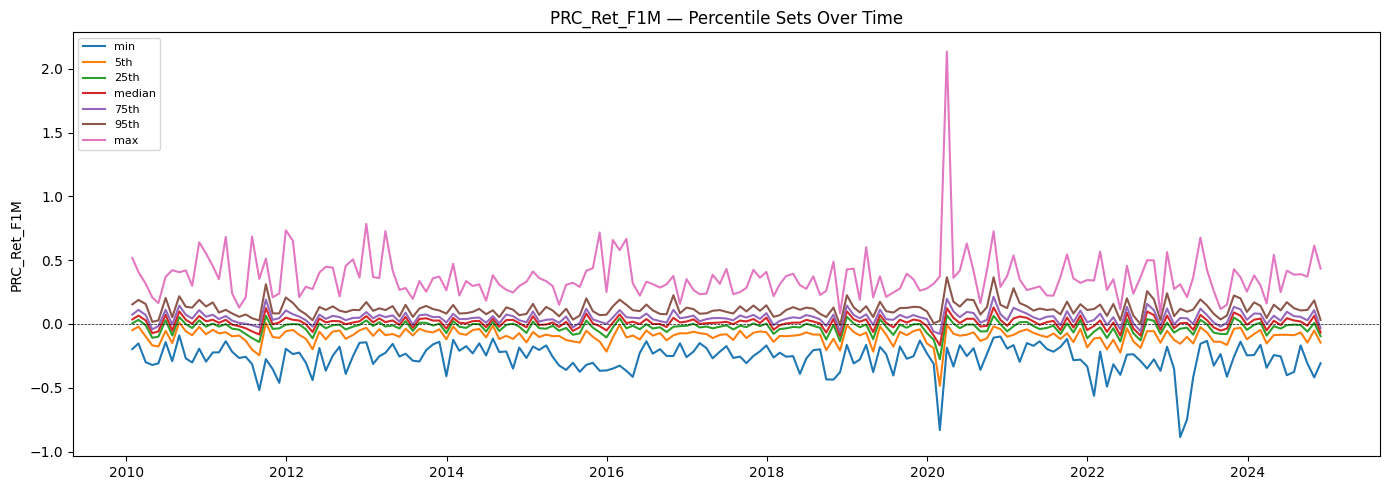

Median of each percentile time series for PRC_Ret_F1M:
       min: -0.2522
       5th: -0.0868
      25th: -0.0213
    median: 0.0125
      75th: 0.0483
      95th: 0.1105
       max: 0.3486



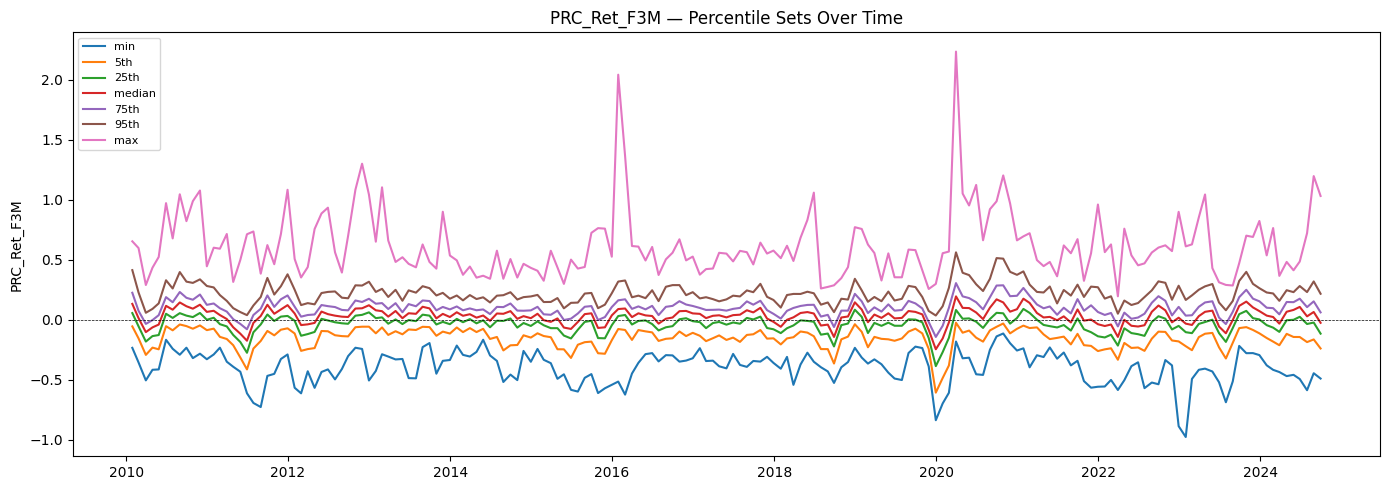

Median of each percentile time series for PRC_Ret_F3M:
       min: -0.3746
       5th: -0.1409
      25th: -0.0276
    median: 0.0363
      75th: 0.1021
      95th: 0.2170
       max: 0.5602



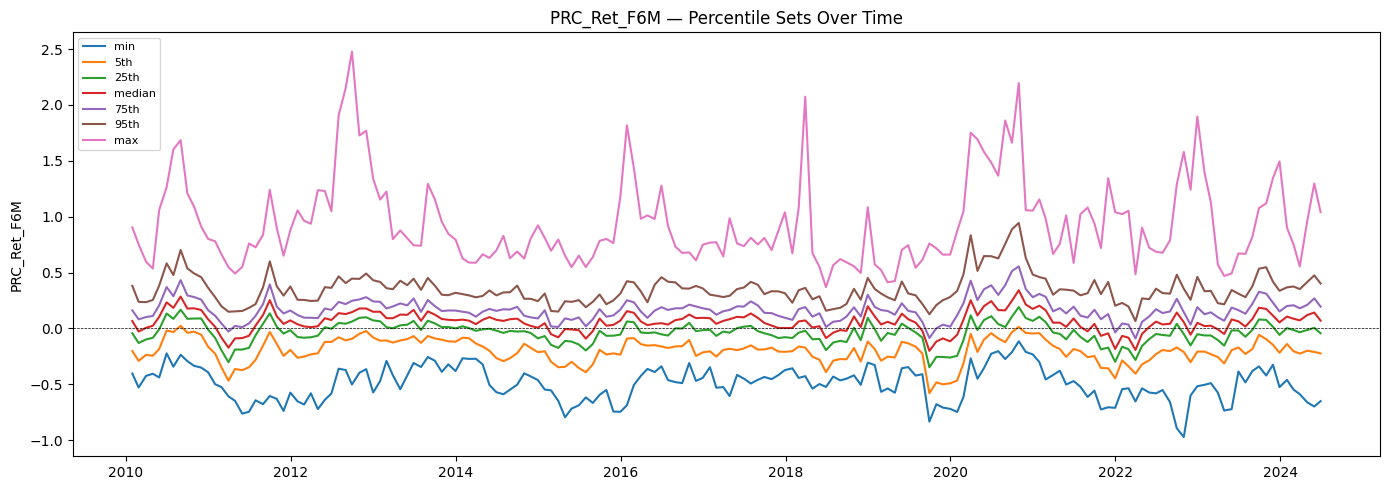

Median of each percentile time series for PRC_Ret_F6M:
       min: -0.4905
       5th: -0.1939
      25th: -0.0350
    median: 0.0679
      75th: 0.1625
      95th: 0.3360
       max: 0.8106



In [23]:
percentiles = [0, 0.05, 0.25, 0.5, 0.75, 0.95, 1.0]
labels = ['min', '5th', '25th', 'median', '75th', '95th', 'max']

signal_cols = [
    'PRC_Ret_T12', 'Prices_Ret_T12',
    'PRC_Ret_T12M1', 'Prices_Ret_T12M1',
    'PRC_Ret_T12_1M', 'Prices_Ret_T12_1M',
    'Vol_Prices_Ret_T12M1', 'SR_Prices_Ret_T12M1',
    'PRC_Ret_F1M', 'PRC_Ret_F3M', 'PRC_Ret_F6M',
]

median_of_percentiles = {}

for col in signal_cols:
    pctiles = DF.groupby('date')[col].quantile(percentiles).unstack()
    pctiles.columns = labels

    ts_medians = pctiles.median()
    median_of_percentiles[col] = ts_medians

    fig, ax = plt.subplots(figsize=(14, 5))
    for lbl in labels:
        ax.plot(pctiles.index, pctiles[lbl], label=lbl)
    ax.set_title(f'{col} — Percentile Sets Over Time')
    ax.set_ylabel(col)
    ax.legend(loc='upper left', fontsize=8)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.tight_layout()
    plt.show()

    print(f"Median of each percentile time series for {col}:")
    for lbl in labels:
        print(f"  {lbl:>8s}: {ts_medians[lbl]:.4f}")
    print()